In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical


In [2]:
import sys
import os

# Add the utils folder to the path
sys.path.append(os.path.abspath("utils"))


In [3]:
data_dir = "dataset"
categories = os.listdir(data_dir)
print("Classes found:", categories)


Classes found: ['closed', 'open']


In [4]:
import os
print("📌 Current Working Directory:", os.getcwd())


📌 Current Working Directory: c:\Users\medip\Downloads\Skillcraft-tech-internship-main\Skillcraft-tech-internship-main\Task 4


In [5]:
img_path = "dataset/open/yourimage.jpg"
print("Trying to load:", img_path)
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)


Trying to load: dataset/open/yourimage.jpg


In [6]:
import os
import cv2
import numpy as np

IMG_SIZE = 64
X = []
y = []

data_dir = 'dataset'
categories = ['open', 'closed']

for idx, category in enumerate(categories):

    folder_path = os.path.join(data_dir, category)

    images = os.listdir(folder_path)

    for img_name in images:

        img_path = os.path.join(folder_path, img_name)

        try:
            img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            X.append(img)
            y.append(idx)

        except Exception as e:
            print("Error loading:", img_path)

X = np.array(X)
y = np.array(y)

print("Dataset Loaded Successfully 🚀")
print("X shape:", X.shape)
print("y shape:", y.shape)


Dataset Loaded Successfully 🚀
X shape: (25, 64, 64)
y shape: (25,)


In [7]:
# Normalize pixel values (0–255) → (0–1)
X = X / 255.0

# Reshape X for model input (SVM needs 2D: samples x features)
X = X.reshape(X.shape[0], -1)

print("Normalized and reshaped X:")
print("X shape:", X.shape)


Normalized and reshaped X:
X shape: (25, 4096)


In [8]:
import numpy as np
from sklearn.model_selection import train_test_split

# Convert to NumPy arrays
X = np.array(X)
y = np.array(y)

# Normalize pixel values (0-255) to 0-1
X = X / 255.0

# Flatten images for SVM (reshape from 64x64 to 4096)
X = X.reshape(len(X), -1)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Data ready for model training ✅")
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")


Data ready for model training ✅
Training set: (20, 4096), Test set: (5, 4096)


In [9]:
from sklearn.svm import SVC
import joblib

# Train SVM model
clf = SVC(kernel='linear', probability=True)
clf.fit(X_train, y_train)

# Save the model
import os
os.makedirs("model", exist_ok=True)  # make sure the model folder exists
joblib.dump(clf, "model/svm_model.pkl")
print("✅ Model trained and saved as model/svm_model.pkl")


✅ Model trained and saved as model/svm_model.pkl



✅ Test Accuracy: 0.40

📋 Classification Report:

              precision    recall  f1-score   support

           0       1.00      0.00      0.00         3
           1       0.40      1.00      0.57         2

    accuracy                           0.40         5
   macro avg       0.70      0.50      0.29         5
weighted avg       0.76      0.40      0.23         5



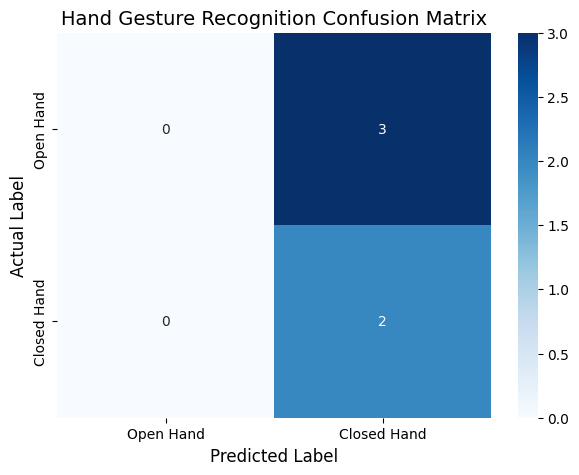

In [10]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Predict on test set
y_pred = clf.predict(X_test)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"\n✅ Test Accuracy: {acc:.2f}")

# Classification Report
print("\n📋 Classification Report:\n")
print(classification_report(y_test, y_pred, zero_division=1))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(7, 5))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Open Hand', 'Closed Hand'],
    yticklabels=['Open Hand', 'Closed Hand']
)

plt.xlabel("Predicted Label", fontsize=12)
plt.ylabel("Actual Label", fontsize=12)
plt.title("Hand Gesture Recognition Confusion Matrix", fontsize=14)

plt.show()


In [11]:
import joblib
import os

# Create model folder if it doesn't exist
os.makedirs("model", exist_ok=True)

# Save the trained model
joblib.dump(clf, "model/svm_model.pkl")
print("✅ Model saved to 'model/svm_model.pkl'")


✅ Model saved to 'model/svm_model.pkl'


In [12]:
def predict_image(img_path, model, img_size=64):
    import cv2
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    img = cv2.resize(img, (img_size, img_size))
    img = img.reshape(1, -1) / 255.0
    prediction = model.predict(img)[0]
    return prediction

# Test a sample image
sample_path = 'dataset/open/hand-gesture-9.jpg'
print("Predicted gesture class:", predict_image(sample_path, clf))


Predicted gesture class: 1


In [13]:
import sys
import os

sys.path.append(os.path.abspath("utils"))
from data_utils import load_dataset

X, y = load_dataset("dataset", img_size=64, max_per_class=50)
print("✅ Loaded from utils!")
print("X shape:", X.shape)
print("y shape:", y.shape)


✅ Loaded from utils!
X shape: (25, 4096)
y shape: (25,)


In [14]:
import sys
import os
sys.path.append(os.path.abspath("utils"))

from data_utils import load_dataset  # Now this should work!
